# DRIVESMART — Phase 2: Data Understanding & EDA

# Step 1: Import Libraries & Load Data

In [22]:

# Core
import pandas as pd
import numpy as np
from pathlib import Path

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# ─────────────────────────────────────────────
# Load data
# ─────────────────────────────────────────────

DATA_DIR = Path('/Users/rupeshmaadas/Documents/Projects/Drivesmart/kayak_data')

df = pd.read_csv(DATA_DIR / 'kayak_San_Jose_20260322_to_20260323_20260316_013841.csv')

# ─────────────────────────────────────────────
# Quick sanity check
# ─────────────────────────────────────────────

print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (638, 8)

Column names:
['Name', 'Name_Element', 'Location', 'Price', 'Provider', 'Start_Date', 'End_Date', 'Extraction_Date']

First 5 rows:


,Name,Name_Element,Location,Price,Provider,Start_Date,End_Date,Extraction_Date
0,Toyota Corolla,or similar Intermediate,SJC: San Jose\nShuttle,$44,Car agency: Payless,2026-03-22,2026-03-23,2026-03-16 01:37:58
1,Toyota Corolla,or similar Intermediate,SJC: San Jose\nShuttle,$44,Car agency: Payless,2026-03-22,2026-03-23,2026-03-16 01:37:58
2,Hyundai Accent,or similar Economy,SJC: San Jose\nShuttle,$44,Car agency: Payless,2026-03-22,2026-03-23,2026-03-16 01:37:58
3,Hyundai Accent,or similar Economy,SJC: San Jose\nShuttle,$44,Car agency: Payless,2026-03-22,2026-03-23,2026-03-16 01:37:58
4,Nissan Versa,or similar Compact,SJC: San Jose\nShuttle,$44,Car agency: Payless,2026-03-22,2026-03-23,2026-03-16 01:37:58


# Step 2: Data Understanding

In [6]:

# ── 2.1 Data types ───────────────────────────
print("=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)

# ── 2.2 Missing values ───────────────────────
print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}))

# ── 2.3 Duplicates ───────────────────────────
print("\n" + "=" * 50)
print("DUPLICATES")
print("=" * 50)
print(f"Total duplicate rows : {df.duplicated().sum()}")
print(f"Unique rows          : {df.shape[0] - df.duplicated().sum()}")

# ── 2.4 Unique values per column ─────────────
print("\n" + "=" * 50)
print("UNIQUE VALUES PER COLUMN")
print("=" * 50)
for col in df.columns:
    print(f"{col:<20} {df[col].nunique():>5} unique values")

# ── 2.5 Sample values per column ─────────────
print("\n" + "=" * 50)
print("SAMPLE VALUES PER COLUMN")
print("=" * 50)
for col in df.columns:
    samples = df[col].dropna().unique()[:4]
    print(f"\n{col}:")
    for s in samples:
        print(f"   → {s}")

DATA TYPES
Name               object
Name_Element       object
Location           object
Price              object
Provider           object
Start_Date         object
End_Date           object
Extraction_Date    object
dtype: object

MISSING VALUES
                 Missing Count  Missing %
Name                         0       0.00
Name_Element                 0       0.00
Location                     0       0.00
Price                        0       0.00
Provider                     0       0.00
Start_Date                   0       0.00
End_Date                     0       0.00
Extraction_Date              0       0.00

DUPLICATES
Total duplicate rows : 297
Unique rows          : 341

UNIQUE VALUES PER COLUMN
Name                   121 unique values
Name_Element            26 unique values
Location                42 unique values
Price                  127 unique values
Provider                28 unique values
Start_Date               1 unique values
End_Date                 1 unique v

# Step 3: Data cleaning

In [35]:
# ── Drop Extraction_Date ─────────────────
df.drop(columns=['Extraction_Date'], inplace=True)
print("Extraction_Date dropped ✓")
print(f"Columns remaining: {df.columns.tolist()}")

Extraction_Date dropped ✓
Columns remaining: ['Name', 'Name_Element', 'Location', 'Price', 'Provider', 'Start_Date', 'End_Date']


In [37]:
df.head()

,Name,Name_Element,Location,Price,Provider,Start_Date,End_Date
0,Toyota Corolla,or similar Intermediate,SJC: San Jose\nShuttle,$44,Car agency: Payless,2026-03-22,2026-03-23
1,Toyota Corolla,or similar Intermediate,SJC: San Jose\nShuttle,$44,Car agency: Payless,2026-03-22,2026-03-23
2,Hyundai Accent,or similar Economy,SJC: San Jose\nShuttle,$44,Car agency: Payless,2026-03-22,2026-03-23
3,Hyundai Accent,or similar Economy,SJC: San Jose\nShuttle,$44,Car agency: Payless,2026-03-22,2026-03-23
4,Nissan Versa,or similar Compact,SJC: San Jose\nShuttle,$44,Car agency: Payless,2026-03-22,2026-03-23


In [29]:
# ── import re ─────────────────────────
import re

# ── Clean leftover 'Vehicle type:' rows in Provider ──
def clean_provider(p):
    if p.startswith('Vehicle type:'):
        return 'Turo'
    return p.strip()

df['Provider'] = df['Provider'].apply(clean_provider)
print(f"Provider fixed ✓ — {df['Provider'].nunique()} unique providers:")
print(df['Provider'].value_counts().to_string())

# ──  Parse Location ────────────────────
def parse_location(loc):
    parts = str(loc).split('\n')
    address = parts[0].strip()
    distance = None
    if len(parts) > 1:
        m = re.search(r'([\d.]+)\s*mi', parts[1])
        if m:
            distance = float(m.group(1))
    return address, distance

df['Pickup_Address'], df['Distance_mi'] = zip(*df['Location'].apply(parse_location))

def pickup_type(addr):
    a = addr.lower()
    if 'airport terminal' in a: return 'Airport Terminal'
    if 'shuttle' in a:           return 'Airport Shuttle'
    if 'call for pick-up' in a:  return 'Call for Pickup'
    if 'exact address' in a:     return 'Turo (Hidden Address)'
    return 'Off-Airport'

df['Pickup_Type'] = df['Pickup_Address'].apply(pickup_type)
print(f"\nLocation parsed ✓")
print(df['Pickup_Type'].value_counts().to_string())

# ── cross check ──────────────────────────────
print("\n" + "=" * 50)
print("CLEANED DATASET SUMMARY")
print("=" * 50)
print(f"Shape         : {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nPrice stats:\n{df['Price'].describe().round(2)}")
df.head()

Provider fixed ✓ — 12 unique providers:
Provider
Turo                     220
Enterprise Rent-A-Car    102
Budget                    44
Avis                      42
Alamo                     42
National                  42
Hertz                     30
Sixt                      26
Dollar                    26
Thrifty                   26
Fox                       22
Payless                   16

Location parsed ✓
Pickup_Type
Off-Airport              450
Turo (Hidden Address)    188

CLEANED DATASET SUMMARY
Shape         : (638, 11)

Missing values:
Name                 0
Name_Element         0
Location             0
Price                0
Provider             0
Start_Date           0
End_Date             0
Extraction_Date      0
Pickup_Address       0
Distance_mi        390
Pickup_Type          0
dtype: int64

Price stats:
count   638.00
mean    137.37
std      90.05
min      39.00
25%      86.25
50%     111.00
75%     155.00
max     639.00
Name: Price, dtype: float64


,Name,Name_Element,Location,Price,Provider,Start_Date,End_Date,Extraction_Date,Pickup_Address,Distance_mi,Pickup_Type
0,Toyota Corolla,or similar Intermediate,SJC: San Jose\nShuttle,44.00,Payless,2026-03-22,2026-03-23,2026-03-16 01:37:58,SJC: San Jose,NaN,Off-Airport
1,Toyota Corolla,or similar Intermediate,SJC: San Jose\nShuttle,44.00,Payless,2026-03-22,2026-03-23,2026-03-16 01:37:58,SJC: San Jose,NaN,Off-Airport
2,Hyundai Accent,or similar Economy,SJC: San Jose\nShuttle,44.00,Payless,2026-03-22,2026-03-23,2026-03-16 01:37:58,SJC: San Jose,NaN,Off-Airport
3,Hyundai Accent,or similar Economy,SJC: San Jose\nShuttle,44.00,Payless,2026-03-22,2026-03-23,2026-03-16 01:37:58,SJC: San Jose,NaN,Off-Airport
4,Nissan Versa,or similar Compact,SJC: San Jose\nShuttle,44.00,Payless,2026-03-22,2026-03-23,2026-03-16 01:37:58,SJC: San Jose,NaN,Off-Airport


In [31]:
# ── Drop duplicates ──────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Duplicates dropped: {before - len(df)} rows removed")
print(f"Rows remaining: {len(df)}")

# ── Drop noise rows from Name_Element ────
noise = [
    'View deal for more details.',
    'Book and save. Vehicle size determined at pick-up.'
]
df = df[~df['Name_Element'].isin(noise)]
df = df[~df['Name_Element'].str.contains('stars|vehicle score', case=False, na=False)]
df.reset_index(drop=True, inplace=True)
print(f"Noise rows dropped — rows remaining: {len(df)}")

# ── Drop Extraction_Date ─────────────────
df.drop(columns=['Extraction_Date'], inplace=True)
print("Extraction_Date dropped ✓")

# ── checking ──────────────────────────────
print("\n" + "=" * 50)
print("FINAL CLEANED DATASET")
print("=" * 50)
print(f"Shape         : {df.shape}")
print(f"\nColumns       : {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Duplicates dropped: 297 rows removed
Rows remaining: 341
Noise rows dropped — rows remaining: 204
Extraction_Date dropped ✓

FINAL CLEANED DATASET
Shape         : (204, 10)

Columns       : ['Name', 'Name_Element', 'Location', 'Price', 'Provider', 'Start_Date', 'End_Date', 'Pickup_Address', 'Distance_mi', 'Pickup_Type']

Missing values:
Name                0
Name_Element        0
Location            0
Price               0
Provider            0
Start_Date          0
End_Date            0
Pickup_Address      0
Distance_mi       174
Pickup_Type         0
dtype: int64


,Name,Name_Element,Location,Price,Provider,Start_Date,End_Date,Pickup_Address,Distance_mi,Pickup_Type
0,Toyota Corolla,or similar Intermediate,SJC: San Jose\nShuttle,44.00,Payless,2026-03-22,2026-03-23,SJC: San Jose,NaN,Off-Airport
1,Hyundai Accent,or similar Economy,SJC: San Jose\nShuttle,44.00,Payless,2026-03-22,2026-03-23,SJC: San Jose,NaN,Off-Airport
2,Nissan Versa,or similar Compact,SJC: San Jose\nShuttle,44.00,Payless,2026-03-22,2026-03-23,SJC: San Jose,NaN,Off-Airport
3,Toyota RAV4,or similar Intermediate SUV,SJC: San Jose\nAirport terminal,62.00,Sixt,2026-03-22,2026-03-23,SJC: San Jose,NaN,Off-Airport
4,BMW X1,or similar Premium SUV,SJC: San Jose\nAirport terminal,68.00,Sixt,2026-03-22,2026-03-23,SJC: San Jose,NaN,Off-Airport


In [38]:
# ── Clean Name_Element ───────────────────────
df['Name_Element'] = df['Name_Element'].str.replace('or similar ', '', regex=False).str.strip()
print("'or similar' removed from Name_Element ✓")
print(df['Name_Element'].value_counts().to_string())
df.head()

'or similar' removed from Name_Element ✓
Name_Element
Minivan                 16
Compact                 15
Intermediate            14
Compact SUV             14
Standard                14
Full-size               14
Passenger van           14
Premium SUV             13
Standard SUV            13
Economy                 13
Full-size SUV           12
Luxury                  12
Intermediate SUV        11
Pickup truck            10
Premium                  8
Luxury SUV               6
Convertible              3
Open air all terrain     1
Premium coupe            1


,Name,Name_Element,Location,Price,Provider,Start_Date,End_Date,Pickup_Address,Distance_mi,Pickup_Type
0,Toyota Corolla,Intermediate,SJC: San Jose\nShuttle,44.00,Payless,2026-03-22,2026-03-23,SJC: San Jose,NaN,Off-Airport
1,Hyundai Accent,Economy,SJC: San Jose\nShuttle,44.00,Payless,2026-03-22,2026-03-23,SJC: San Jose,NaN,Off-Airport
2,Nissan Versa,Compact,SJC: San Jose\nShuttle,44.00,Payless,2026-03-22,2026-03-23,SJC: San Jose,NaN,Off-Airport
3,Toyota RAV4,Intermediate SUV,SJC: San Jose\nAirport terminal,62.00,Sixt,2026-03-22,2026-03-23,SJC: San Jose,NaN,Off-Airport
4,BMW X1,Premium SUV,SJC: San Jose\nAirport terminal,68.00,Sixt,2026-03-22,2026-03-23,SJC: San Jose,NaN,Off-Airport


# Step 4: Feature Engineering

In [43]:
# ── Fix: Convert dates to datetime ───────────
df['Start_Date'] = pd.to_datetime(df['Start_Date'])
df['End_Date']   = pd.to_datetime(df['End_Date'])
print(f"Dates converted ✓")
print(f"Start_Date dtype: {df['Start_Date'].dtype}")
print(f"End_Date dtype  : {df['End_Date'].dtype}")

# ── 4.1 Rental Days ──────────────────────────
df['Rental_Days'] = (df['End_Date'] - df['Start_Date']).dt.days
print(f"\nRental_Days → unique values: {df['Rental_Days'].unique()}")

# ── 4.2 Passenger Capacity ───────────────────
capacity_map = {
    'Economy'            : 4,
    'Compact'            : 5,
    'Intermediate'       : 5,
    'Standard'           : 5,
    'Full-size'          : 5,
    'Premium'            : 5,
    'Luxury'             : 5,
    'Convertible'        : 2,
    'Premium coupe'      : 2,
    'Compact SUV'        : 5,
    'Intermediate SUV'   : 5,
    'Standard SUV'       : 5,
    'Full-size SUV'      : 7,
    'Premium SUV'        : 7,
    'Luxury SUV'         : 7,
    'Minivan'            : 7,
    'Passenger van'      : 12,
    'Pickup truck'       : 5,
    'Open air all terrain': 4,
}
df['Passenger_Capacity'] = df['Name_Element'].map(capacity_map)
print(f"\nPassenger_Capacity mapped ✓")
print(df['Passenger_Capacity'].value_counts().to_string())
print(f"Unmapped rows: {df['Passenger_Capacity'].isnull().sum()}")

# ── 4.3 Price Tier ───────────────────────────
tier_map = {
    'Economy'            : 'Budget',
    'Compact'            : 'Budget',
    'Intermediate'       : 'Budget',
    'Standard'           : 'Mid-Range',
    'Full-size'          : 'Mid-Range',
    'Compact SUV'        : 'Mid-Range',
    'Intermediate SUV'   : 'Mid-Range',
    'Standard SUV'       : 'Mid-Range',
    'Full-size SUV'      : 'Mid-Range',
    'Minivan'            : 'Mid-Range',
    'Pickup truck'       : 'Mid-Range',
    'Open air all terrain': 'Mid-Range',
    'Premium'            : 'Premium',
    'Luxury'             : 'Premium',
    'Convertible'        : 'Premium',
    'Premium SUV'        : 'Premium',
    'Luxury SUV'         : 'Premium',
    'Premium coupe'      : 'Premium',
    'Passenger van'      : 'Specialty',
}
df['Price_Tier'] = df['Name_Element'].map(tier_map)
print(f"\nPrice_Tier distribution:")
print(df['Price_Tier'].value_counts().to_string())

# ── 4.4 Is Turo flag ─────────────────────────
df['Is_Turo'] = (df['Provider'] == 'Turo').astype(int)
print(f"\nIs_Turo → Turo: {df['Is_Turo'].sum()}, Agency: {(df['Is_Turo'] == 0).sum()}")

# ── Final check ──────────────────────────────
print("\n" + "=" * 50)
print("AFTER FEATURE ENGINEERING")
print("=" * 50)
print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Dates converted ✓
Start_Date dtype: datetime64[ns]
End_Date dtype  : datetime64[ns]

Rental_Days → unique values: [1]

Passenger_Capacity mapped ✓
Passenger_Capacity
5     125
7      47
4      14
12     14
2       4
Unmapped rows: 0

Price_Tier distribution:
Price_Tier
Mid-Range    105
Premium       43
Budget        42
Specialty     14

Is_Turo → Turo: 11, Agency: 193

AFTER FEATURE ENGINEERING
Shape   : (204, 14)
Columns : ['Name', 'Name_Element', 'Location', 'Price', 'Provider', 'Start_Date', 'End_Date', 'Pickup_Address', 'Distance_mi', 'Pickup_Type', 'Rental_Days', 'Passenger_Capacity', 'Price_Tier', 'Is_Turo']

Missing values:
Name                    0
Name_Element            0
Location                0
Price                   0
Provider                0
Start_Date              0
End_Date                0
Pickup_Address          0
Distance_mi           174
Pickup_Type             0
Rental_Days             0
Passenger_Capacity      0
Price_Tier              0
Is_Turo                

,Name,Name_Element,Location,Price,Provider,Start_Date,End_Date,Pickup_Address,Distance_mi,Pickup_Type,Rental_Days,Passenger_Capacity,Price_Tier,Is_Turo
0,Toyota Corolla,Intermediate,SJC: San Jose\nShuttle,44.00,Payless,2026-03-22,2026-03-23,SJC: San Jose,NaN,Off-Airport,1,5,Budget,0
1,Hyundai Accent,Economy,SJC: San Jose\nShuttle,44.00,Payless,2026-03-22,2026-03-23,SJC: San Jose,NaN,Off-Airport,1,4,Budget,0
2,Nissan Versa,Compact,SJC: San Jose\nShuttle,44.00,Payless,2026-03-22,2026-03-23,SJC: San Jose,NaN,Off-Airport,1,5,Budget,0
3,Toyota RAV4,Intermediate SUV,SJC: San Jose\nAirport terminal,62.00,Sixt,2026-03-22,2026-03-23,SJC: San Jose,NaN,Off-Airport,1,5,Mid-Range,0
4,BMW X1,Premium SUV,SJC: San Jose\nAirport terminal,68.00,Sixt,2026-03-22,2026-03-23,SJC: San Jose,NaN,Off-Airport,1,7,Premium,0


# Step 5: Exploratory Data Analysis (EDA)

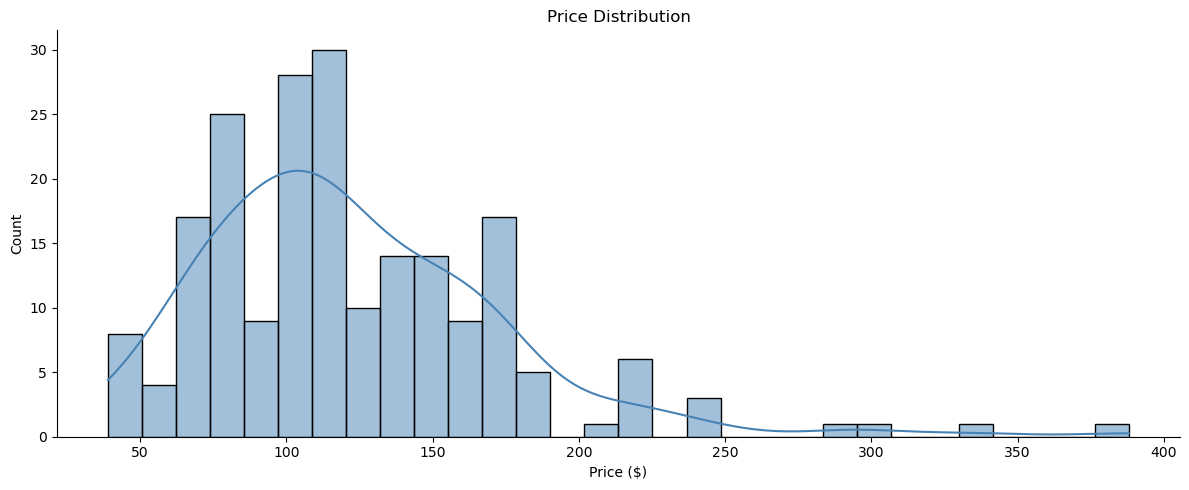

Price stats:
count   204.00
mean    122.36
std      52.05
min      39.00
25%      85.00
50%     113.50
75%     149.00
max     388.00
Name: Price, dtype: float64


In [46]:

# ── 5.1 Price Distribution ───────────────────
plt.figure(figsize=(12, 5))
sns.histplot(df['Price'], bins=30, kde=True, color='steelblue')
plt.title('Price Distribution')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Price stats:\n{df['Price'].describe().round(2)}")

/var/folders/ms/64k7m32s28g2bl17yfbs08z80000gn/T/ipykernel_1978/1282212542.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Name_Element', y='Price', order=order, palette='Blues')


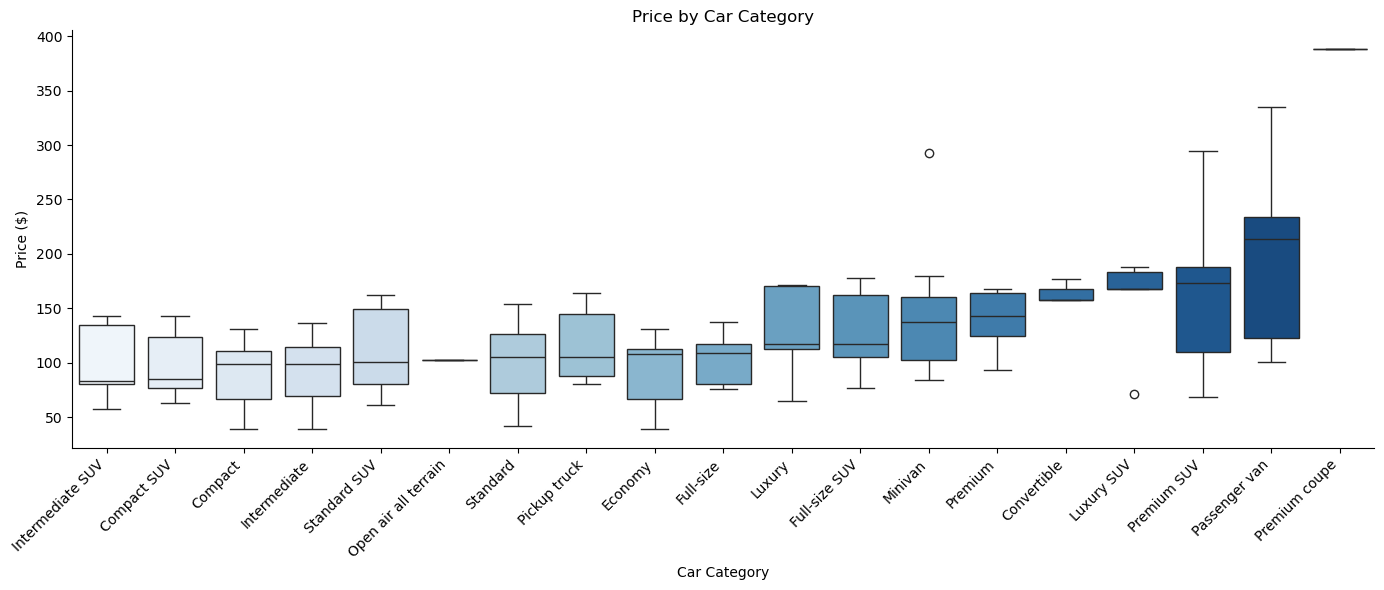

In [48]:
# ── 5.2 Price by Car Category ────────────────
plt.figure(figsize=(14, 6))
order = df.groupby('Name_Element')['Price'].median().sort_values().index
sns.boxplot(data=df, x='Name_Element', y='Price', order=order, palette='Blues')
plt.xticks(rotation=45, ha='right')
plt.title('Price by Car Category')
plt.xlabel('Car Category')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

/var/folders/ms/64k7m32s28g2bl17yfbs08z80000gn/T/ipykernel_1978/554818249.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Provider', y='Price', order=order, palette='Blues_d', ci=None)
/var/folders/ms/64k7m32s28g2bl17yfbs08z80000gn/T/ipykernel_1978/554818249.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Provider', y='Price', order=order, palette='Blues_d', ci=None)


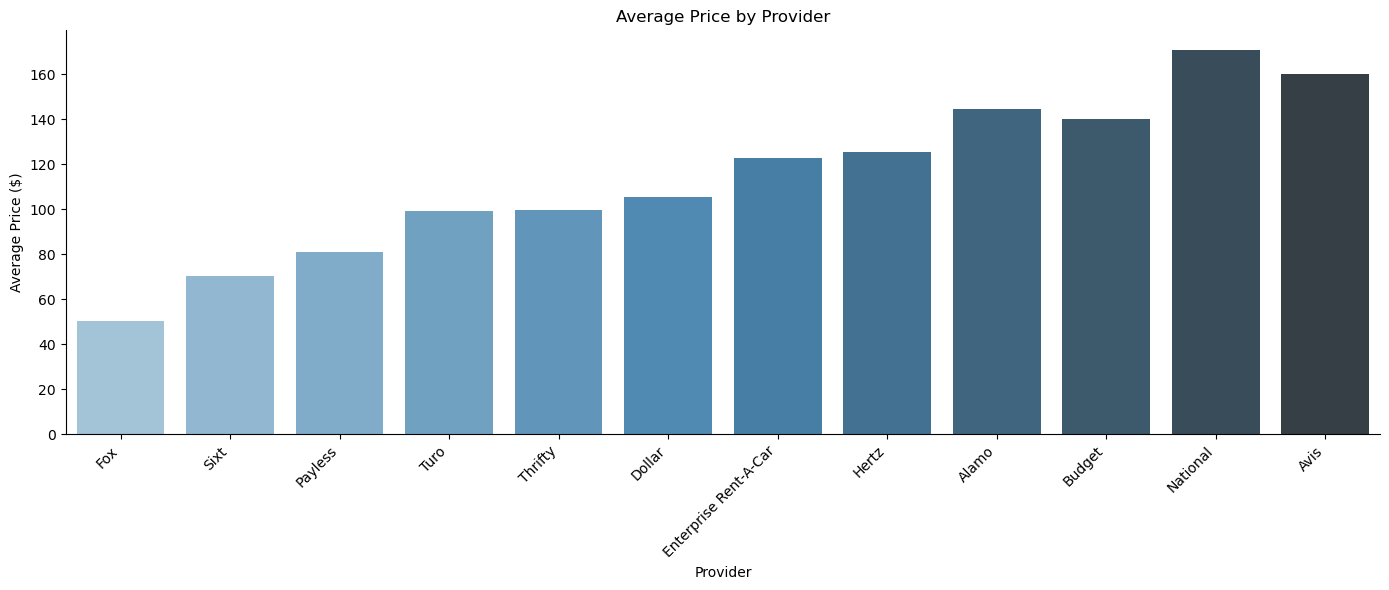

In [50]:
# ── 5.3 Price by Provider ────────────────────
plt.figure(figsize=(14, 6))
order = df.groupby('Provider')['Price'].median().sort_values().index
sns.barplot(data=df, x='Provider', y='Price', order=order, palette='Blues_d', ci=None)
plt.xticks(rotation=45, ha='right')
plt.title('Average Price by Provider')
plt.xlabel('Provider')
plt.ylabel('Average Price ($)')
plt.tight_layout()
plt.show()

/var/folders/ms/64k7m32s28g2bl17yfbs08z80000gn/T/ipykernel_1978/2236352306.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pickup_Type', y='Price', order=order, palette='Blues')


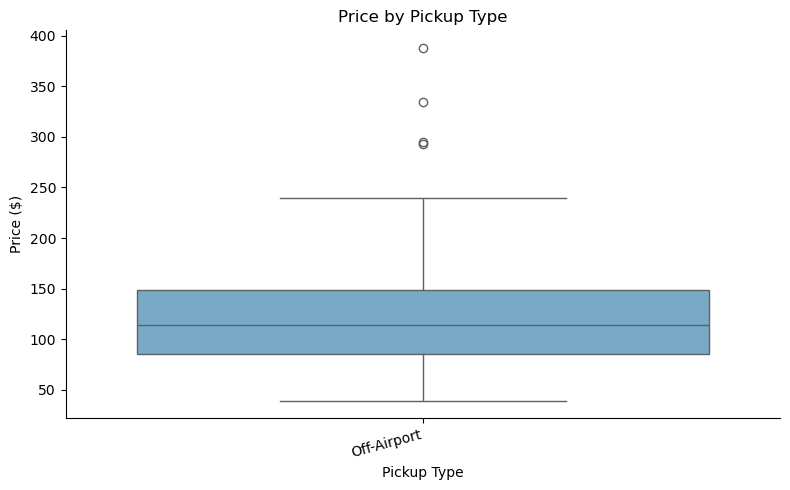

In [52]:
# ── 5.4 Price by Pickup Type ─────────────────
plt.figure(figsize=(8, 5))
order = df.groupby('Pickup_Type')['Price'].median().sort_values().index
sns.boxplot(data=df, x='Pickup_Type', y='Price', order=order, palette='Blues')
plt.xticks(rotation=15, ha='right')
plt.title('Price by Pickup Type')
plt.xlabel('Pickup Type')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

/var/folders/ms/64k7m32s28g2bl17yfbs08z80000gn/T/ipykernel_1978/1932261067.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Price_Tier', y='Price', order=order, palette='Blues')


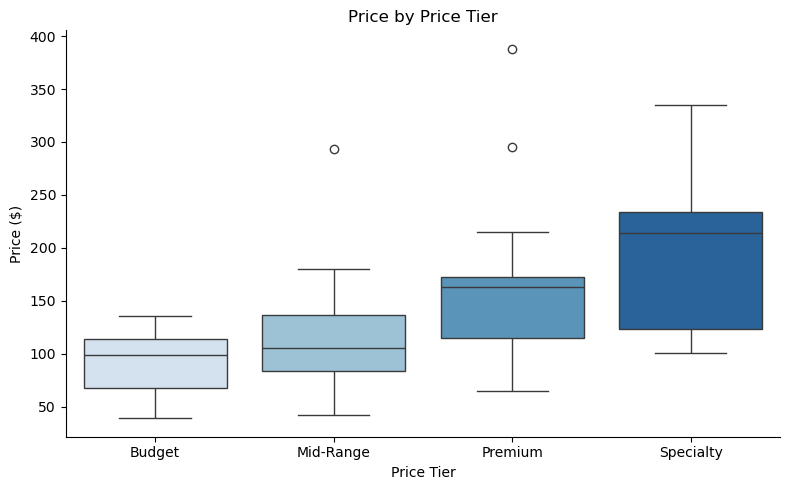

In [54]:
# ── 5.5 Price by Price Tier ──────────────────
plt.figure(figsize=(8, 5))
order = ['Budget', 'Mid-Range', 'Premium', 'Specialty']
sns.boxplot(data=df, x='Price_Tier', y='Price', order=order, palette='Blues')
plt.title('Price by Price Tier')
plt.xlabel('Price Tier')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()